In [3]:
import numpy as np
import matplotlib.pyplot as plt

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
print(colors)

PRIMARY_COLOR = colors[0]

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


# Kansfunctie en CDF

Samples: [4 2 5 3 0 6 4 4 1 2]
[0 1 2 3 4 5 6] {0: 0.1, 1: 0.30000000000000004, 2: 0.5, 3: 0.7, 4: 0.85, 5: 0.95, 6: 1.0}
0 0 0 0.1
1 1 0.1 0.30000000000000004
2 2 0.30000000000000004 0.5
3 3 0.5 0.7
4 4 0.7 0.85
5 5 0.85 0.95
6 6 0.95 1.0


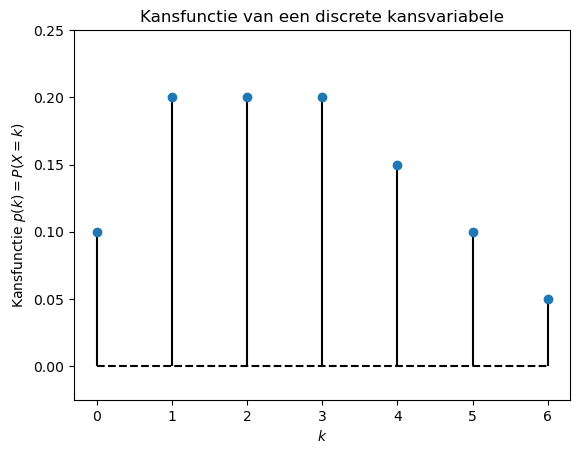

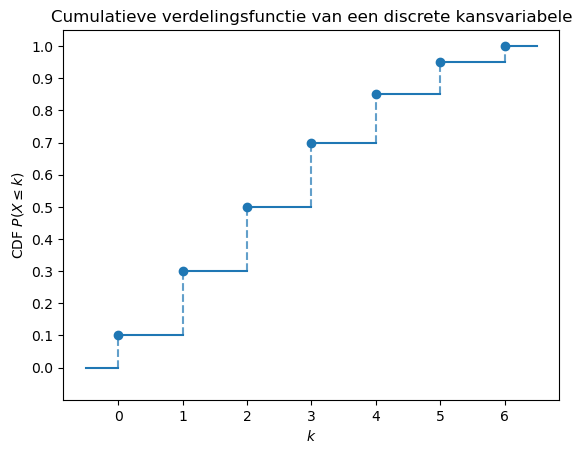

In [19]:
def validate_distribution(states, probs, tol=1e-8):
    """
    Validates that probabilities form a proper discrete distribution.
    """
    states = np.array(states)
    probs = np.array(probs)

    if len(states) != len(probs):
        raise ValueError("States and probabilities must have the same length.")

    if np.any(probs < 0):
        raise ValueError("Probabilities must be non-negative.")

    if not np.isclose(np.sum(probs), 1.0, atol=tol):
        raise ValueError("Probabilities must sum to 1.")

    return states, probs


def sample_discrete(states, probs, size=1, random_state=None):
    """
    Draw samples from a discrete distribution.
    """
    states, probs = validate_distribution(states, probs)

    rng = np.random.default_rng(random_state)
    samples = rng.choice(states, size=size, p=probs)

    return samples


def compute_cdf(states, probs):
    """
    Computes the CDF values for a discrete distribution.
    Returns sorted states and corresponding CDF values.
    """
    states, probs = validate_distribution(states, probs)

    # Sort by states
    sorted_indices = np.argsort(states)
    states_sorted = states[sorted_indices]
    probs_sorted = probs[sorted_indices]

    cdf = np.cumsum(probs_sorted)
    cdf = {k: v for (k, v) in zip(states_sorted, cdf)}

    return states_sorted, cdf


def plot_pmf(states, probs, title="PMF", xlabel="$x$", ylabel="$y$"):
    """
    Plots the probability mass function using a stem plot.
    """
    states, probs = validate_distribution(states, probs)

    plt.figure()
    markerline, stemlines, baseline = plt.stem(states, probs)
    plt.setp(markerline, 'markerfacecolor', PRIMARY_COLOR)
    plt.setp(stemlines, 'color', 'black')
    plt.setp(baseline, 'color', 'black', 'linestyle', 'dashed')

    xmin = int(np.floor(min(states)))
    xmax = int(np.ceil(max(states)))
    plt.xticks(np.arange(xmin, xmax + 1, 1))
    plt.yticks(np.arange(0, 0.3, 0.05))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.ylim(-0.025, 0.25)
    plt.savefig("./Figures/2_example_discrete_kansfunctie.png")


def plot_cdf(states, probs, title="CDF", xlabel="$x$", ylabel="$y$"):
    """
    Plots the cumulative distribution function using a step plot.
    """
    states_sorted, cdf = compute_cdf(states, probs)

    plt.figure()
    print(states_sorted, cdf)
    plt.plot([-0.5, 0], [0,0], color=PRIMARY_COLOR)
    for x1, x2 in zip(states_sorted, states_sorted[1:]):
        plt.plot([x1,x2], [cdf[x1], cdf[x1]], color=PRIMARY_COLOR)

    # Add dashed vertical lines for jumps
    prev_cdf = 0
    for x, c in cdf.items():
        print(x,x, prev_cdf,c)
        plt.scatter([x], [cdf[x]], color=PRIMARY_COLOR)
        plt.plot([x,x], [prev_cdf, c], linestyle='dashed', alpha=0.7, color=PRIMARY_COLOR)
        prev_cdf = c

    maximum = max(cdf.keys(), key=lambda x: cdf[x])
    plt.plot([maximum, maximum + 0.5], [cdf[maximum], cdf[maximum]], color=PRIMARY_COLOR)

    # Afdwingen: ieder geheel getal is zichtbaar als as tick
    xmin = int(np.floor(min(states)))
    xmax = int(np.ceil(max(states)))
    plt.xticks(np.arange(xmin, xmax + 1, 1))
    plt.yticks(np.arange(0, 1.2, 0.1))
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.ylim(-0.1, 1.05)
    # plt.grid(True)
    plt.savefig("./Figures/2_example_discrete_CDF.png")

# Example usage
if __name__ == "__main__":
    states = [0,1,2,3,4,5,6]#[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    probs = [0.10, 0.20, 0.20, 0.20, 0.15, 0.10, 0.05]#[0.10, 0.09, 0.12, 0.07, 0.15, 0.09, 0.08, 0.07, 0.10, 0.13]

    # Sample
    samples = sample_discrete(states, probs, size=10, random_state=42)
    print("Samples:", samples)

    # Plot PMF
    plot_pmf(states, probs, title="Kansfunctie van een discrete kansvariabele", xlabel="$k$", ylabel="Kansfunctie $p(k) = P(X=k)$")

    # Plot CDF
    plot_cdf(states, probs, title="Cumulatieve verdelingsfunctie van een discrete kansvariabele", xlabel="$k$", ylabel="CDF $P(X \\leq k)$")